In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Verify GPU is available
print(tf.config.list_physical_devices('GPU'))

# Mixed precision: uses float16 on GPU for ~2x speedup on Ada/Ampere GPUs
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# XLA JIT compilation for additional ~10-20% speedup
tf.config.optimizer.set_jit(True)

I0000 00:00:1781218646.259212  112298 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781218646.350224  112298 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781218649.141564  112298 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [4]:
import numpy as np

# Offline augmentation: add horizontally flipped copies → doubles training set
train_images_flipped = train_images[:, :, ::-1, :]  # flip along width axis
train_images = np.concatenate([train_images, train_images_flipped], axis=0)
train_labels = np.concatenate([train_labels, train_labels], axis=0)

print(f"Training set size after augmentation: {train_images.shape[0]} images")  # 100,000

Training set size after augmentation: 100000 images


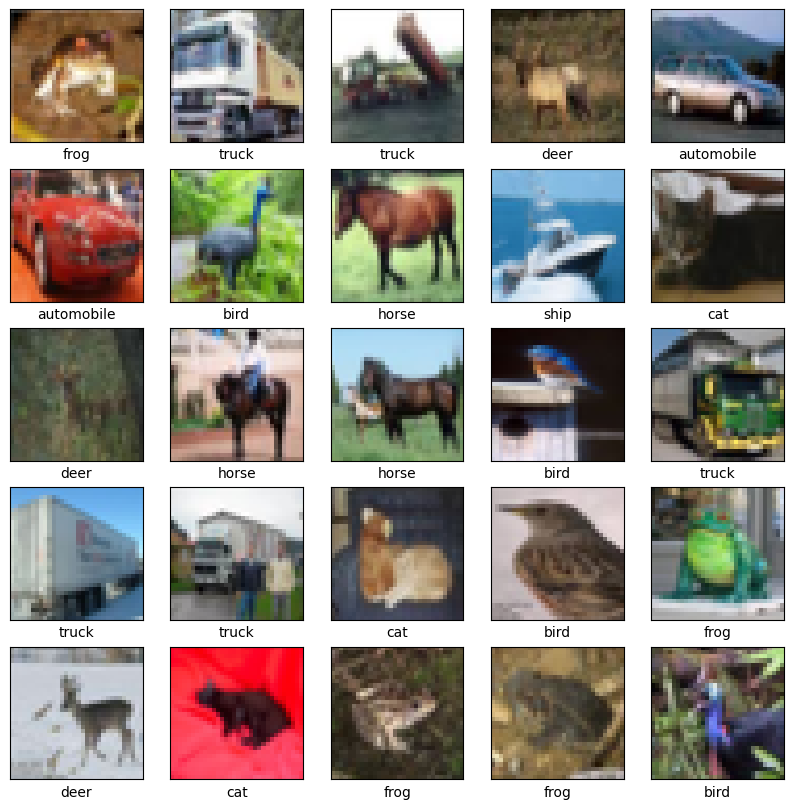

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

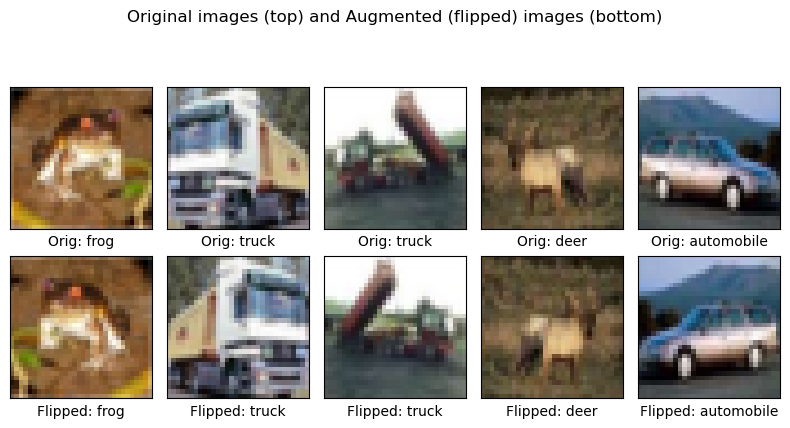

In [6]:
# Show an example of initial images and their horizontally flipped augmented versions

plt.figure(figsize=(8,4))
for i in range(5):
    # Show the original image
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(f"Orig: {class_names[train_labels[i][0]]}")
    # Show the corresponding flipped image
    plt.subplot(2,5,i+6)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Since train_images_flipped is a flipped copy of the first batch of images
    plt.imshow(train_images_flipped[i])
    plt.xlabel(f"Flipped: {class_names[train_labels[i][0]]}")

plt.suptitle("Original images (top) and Augmented (flipped) images (bottom)", y=1.05)
plt.tight_layout()
plt.show()


In [7]:
inputs = layers.Input(shape=(32, 32, 3))

# Augmentation
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomTranslation(0.125, 0.125, fill_mode='reflect')(x)

# Block 1
x = layers.Conv2D(8, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(16, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2 — with skip connection (projection shortcut 16 → 32)
skip = x
skip = layers.Conv2D(32, (1, 1), padding='same')(skip)
skip = layers.BatchNormalization()(skip)

x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Add()([x, skip])
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3 — 3 conv layers in residual path (deepened)
skip = x
skip = layers.Conv2D(64, (1, 1), padding='same')(skip)
skip = layers.BatchNormalization()(skip)

x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Add()([x, skip])
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, dtype='float32')(x)

model = models.Model(inputs, outputs)
model.summary()

I0000 00:00:1781218659.653782  112298 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32, 8) │        224 │ random_translati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32, 8) │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,168 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        544 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                 

 Total params: 112,442 (439.23 KB)

 Trainable params: 111,690 (436.29 KB)

 Non-trainable params: 752 (2.94 KB)

In [8]:
BATCH_SIZE = 256

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .shuffle(100000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

history = model.fit(train_ds, epochs=100, validation_data=val_ds, callbacks=[early_stop])

Epoch 1/100


I0000 00:00:1781218674.154883  112655 service.cc:153] XLA service 0x7684b803f2e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781218674.154935  112655 service.cc:161]   StreamExecutor [0]: NVIDIA RTX 2000 Ada Generation Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781218674.181127  112655 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781218674.288903  112655 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1781218678.950963  112298 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1781218682.168916  112656 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781218683.218416  112656 dot_merger.cc:481] Mergi

391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - loss: 1.4783 - val_loss: 1.3593
Epoch 2/100
389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1427

I0000 00:00:1781218756.926569  112652 dot_merger.cc:481] Merging Dots in computation: cluster_4__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_42_.128


391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - loss: 1.0956 - val_loss: 1.0562
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.9360 - val_loss: 0.9521
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.8280 - val_loss: 0.8566
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.7552 - val_loss: 0.8957
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.7012 - val_loss: 0.7310
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.6617 - val_loss: 0.8345
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.6247 - val_loss: 0.8757
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5957 - val_loss: 0.6647
Epoch 10/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5705 - val_loss: 0.8258
Epoch 11/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5518 - val_loss: 0.7907
Epoch 12/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5333 - val_loss: 0.6821
Epoch 13/100
391/391 ━━━━━━━━━━━━━━━━━━

313/313 - 6s - 20ms/step - loss: 0.4940


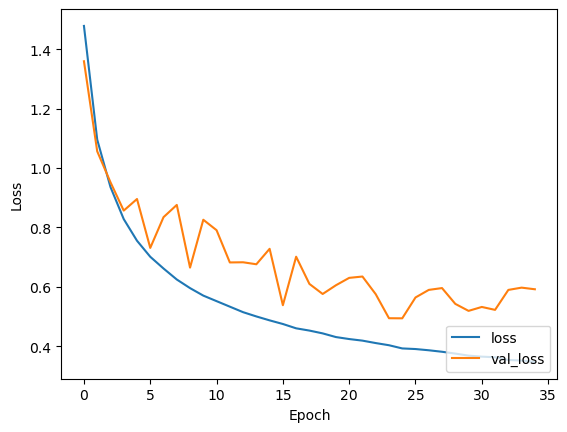

In [9]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

test_loss = model.evaluate(test_images, test_labels, verbose=2)

In [10]:
print(test_loss)

0.4940197169780731
